<a href="https://colab.research.google.com/github/anjitha2002/google-stock-Price-prediction-using-LSTM/blob/main/google_stock_Price_prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers,models

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
data=pd.read_csv("/content/GOOG-selected-columns.csv")

In [ ]:
data

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.470,713.1200,716.48,1306065,718.27,722.470,713.1200
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.980,717.3100,719.00,1214517,718.92,722.980,717.3100
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.650,703.2600,714.91,1982471,710.36,716.650,703.2600
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.820,688.4515,708.65,3402357,691.72,708.820,688.4515
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.480,693.4100,698.77,2082538,693.71,702.480,693.4100
...,...,...,...,...,...,...,...,...,...,...
1253,GOOG,2021-06-07 00:00:00+00:00,2466.09,2468.000,2441.0725,2451.32,1192453,2466.09,2468.000,2441.0725
1254,GOOG,2021-06-08 00:00:00+00:00,2482.85,2494.495,2468.2400,2479.90,1253253,2482.85,2494.495,2468.2400
1255,GOOG,2021-06-09 00:00:00+00:00,2491.40,2505.000,2487.3300,2499.50,1006337,2491.40,2505.000,2487.3300
1256,GOOG,2021-06-10 00:00:00+00:00,2521.60,2523.260,2494.0000,2494.01,1561733,2521.60,2523.260,2494.0000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   symbol    1258 non-null   object 
 1   date      1258 non-null   object 
 2   close     1258 non-null   float64
 3   high      1258 non-null   float64
 4   low       1258 non-null   float64
 5   open      1258 non-null   float64
 6   volume    1258 non-null   int64  
 7   adjClose  1258 non-null   float64
 8   adjHigh   1258 non-null   float64
 9   adjLow    1258 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 98.4+ KB


In [ ]:
data.isnull().sum()

,0
symbol,0
date,0
close,0
high,0
low,0
open,0
volume,0
adjClose,0
adjHigh,0
adjLow,0


In [ ]:
data1=data[['close']]

In [ ]:
data1

,close
0,718.27
1,718.92
2,710.36
3,691.72
4,693.71
...,...
1253,2466.09
1254,2482.85
1255,2491.40
1256,2521.60


In [ ]:
import matplotlib.pyplot as plt

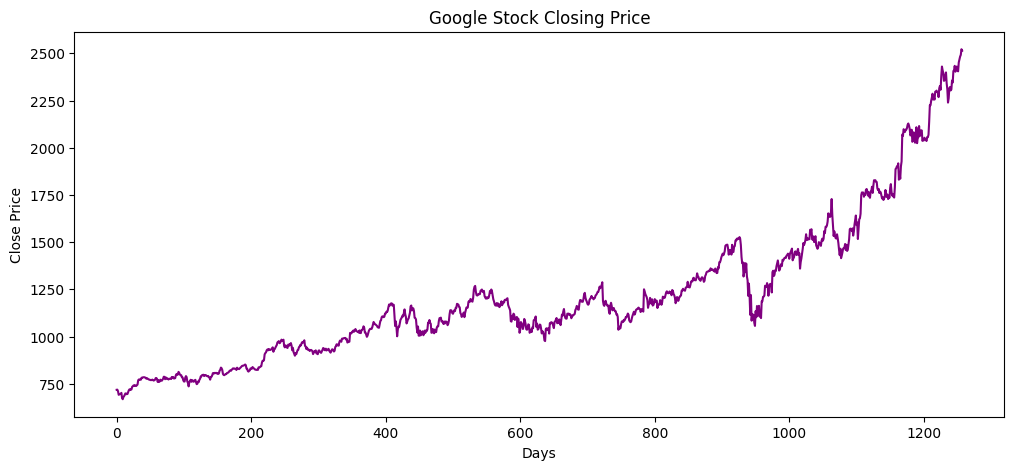

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(data1['close'],color='purple')

plt.title('Google Stock Closing Price')
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data1.values)

In [ ]:
timestep=60
x=[]
y=[]

for i in range(timestep,len(scaled_data)):
  x.append(scaled_data[i-timestep:i,0])
  y.append(scaled_data[i,0])

x=np.array(x)
y=np.array(y)

In [ ]:
x=x.reshape(x.shape[0],x.shape[1],1)

In [ ]:
x

array([[[0.02698372],
        [0.02733443],
        [0.02271575],
        ...,
        [0.05568325],
        [0.06033432],
        [0.06048   ]],

       [[0.02733443],
        [0.02271575],
        [0.01265823],
        ...,
        [0.06033432],
        [0.06048   ],
        [0.05776598]],

       [[0.02271575],
        [0.01265823],
        [0.01373196],
        ...,
        [0.06048   ],
        [0.05776598],
        [0.04931637]],

       ...,

       [[0.75443793],
        [0.76848285],
        [0.76770587],
        ...,
        [0.96231668],
        [0.97004867],
        [0.9790918 ]],

       [[0.76848285],
        [0.76770587],
        [0.73810526],
        ...,
        [0.97004867],
        [0.9790918 ],
        [0.98370509]],

       [[0.76770587],
        [0.73810526],
        [0.74187143],
        ...,
        [0.9790918 ],
        [0.98370509],
        [1.        ]]])

In [ ]:
print(x.shape)

(1198, 60, 1)


In [ ]:
print(y.shape)

(1198,)


In [ ]:
# split data for training and testing

from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,shuffle=False
)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(958, 60, 1)
(240, 60, 1)


In [ ]:
model=models.Sequential([

    layers.LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)),
    layers.Dropout(0.2),
    layers.LSTM(units=50,return_sequences=False),
    layers.Dropout(0.2),

    # classification output
    layers.Dense(units=1)
],name="Stock-prediction")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "Stock-prediction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model compile

model.compile(optimizer="adam",
              loss='mean_squared_error',
              metrics=['mae'])

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1

    )

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0055 - mae: 0.0537 - val_loss: 0.0081 - val_mae: 0.0758
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - mae: 0.0254 - val_loss: 0.0014 - val_mae: 0.0305
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4848e-04 - mae: 0.0228 - val_loss: 0.0031 - val_mae: 0.0452
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.1047e-04 - mae: 0.0223 - val_loss: 0.0045 - val_mae: 0.0571
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0906e-04 - mae: 0.0212 - val_loss: 0.0012 - val_mae: 0.0278
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.2510e-04 - mae: 0.0213 - val_loss: 0.0015 - val_mae: 0.0300
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0685e-04 - mae: 0.0204 - val_loss: 0.0021 - val_mae: 0.0363
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8091e-04 - mae: 0.0208 - val_loss: 0.0022 - val_mae: 0.0371
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)
print("Test accuracy",accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0359     
Test accuracy 0.03588129207491875


In [ ]:
prediction=model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [ ]:
print(prediction)

[[0.39757526]
 [0.39341617]
 [0.39387012]
 [0.39916468]
 [0.40908575]
 [0.418741  ]
 [0.42779726]
 [0.4364518 ]
 [0.44636333]
 [0.45206136]
 [0.45553797]
 [0.45640016]
 [0.456066  ]
 [0.4547574 ]
 [0.4579956 ]
 [0.46200937]
 [0.4667226 ]
 [0.46565711]
 [0.4615929 ]
 [0.45841086]
 [0.4531362 ]
 [0.44990408]
 [0.44909424]
 [0.4449116 ]
 [0.4391222 ]
 [0.43262935]
 [0.42778516]
 [0.42719895]
 [0.42836273]
 [0.43053108]
 [0.43141532]
 [0.43418378]
 [0.4385664 ]
 [0.44199634]
 [0.44542307]
 [0.45221603]
 [0.45833117]
 [0.46647424]
 [0.47395426]
 [0.48052746]
 [0.48737854]
 [0.49744236]
 [0.5052803 ]
 [0.51159024]
 [0.51475567]
 [0.5183207 ]
 [0.5280759 ]
 [0.52993923]
 [0.52254856]
 [0.50588644]
 [0.4899882 ]
 [0.4744805 ]
 [0.4608245 ]
 [0.45043206]
 [0.44580704]
 [0.44305497]
 [0.4395979 ]
 [0.43324602]
 [0.4240343 ]
 [0.41847116]
 [0.41091502]
 [0.40519845]
 [0.4030714 ]
 [0.40512747]
 [0.40957415]
 [0.4146846 ]
 [0.42138273]
 [0.42470896]
 [0.4285494 ]
 [0.42871404]
 [0.4276917 ]
 [0.42

In [ ]:
predicted=scaler.inverse_transform(prediction)
actual=scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
print(predicted.shape)

(240, 1)


In [ ]:
print(actual.shape)

(240, 1)


In [ ]:
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(actual,predicted)
print("MSE:",mse)
rmse=np.sqrt(mse)
print("RMSE:",rmse)

MSE: 7076.755807738248
RMSE: 84.1234557524728


In [ ]:
import matplotlib.pyplot as plt

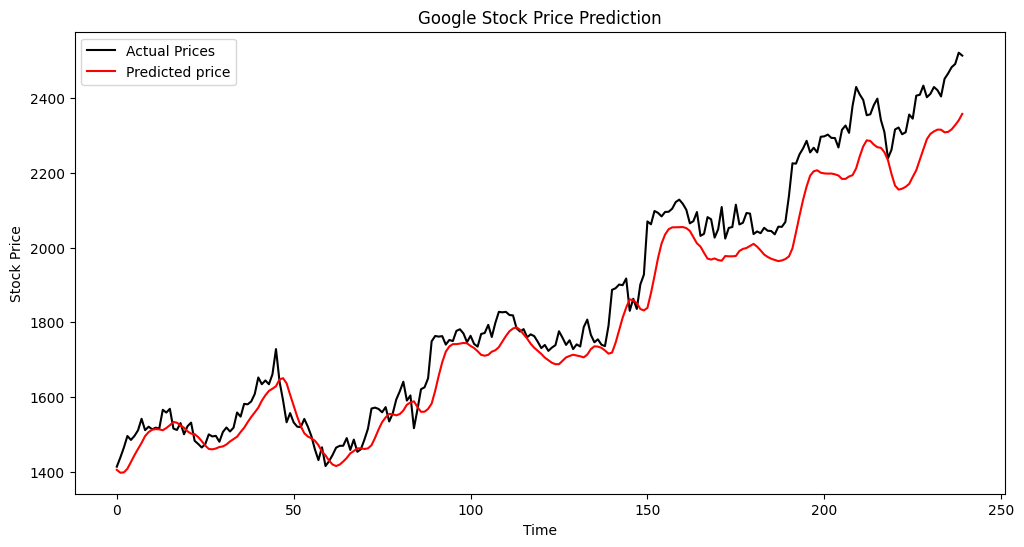

In [ ]:


plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual Prices', color='black')
plt.plot(predicted, label='Predicted price', color='red')
plt.legend()
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.show()

